In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import funcs
import imp
import random
import mne
from scipy.signal import hilbert
imp.reload(funcs)
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm


# Import the FOOOF object
from fooof import FOOOF

# Import some internal functions
#   These are used here to demonstrate the algorithm
#   You do not need to import these functions for standard usage of the module
from fooof.sim.gen import gen_aperiodic
from fooof.plts.spectra import plot_spectra
from fooof.plts.annotate import plot_annotated_peak_search

C:\Users\Tianyi Zheng\AppData\Local\Temp\ipykernel_26480\1452165549.py:11: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp


In [2]:
load_path = os.path.join('..', '..', '..', 'data', 'subjects_behavior_eeg.pkl')
subjects_behavior_eeg = pd.read_pickle(load_path)
# 30.4s

In [3]:
subjects_behavior_fooof = funcs.load_subjects_behavior()
subjects_behavior_fooof["exponent"] = None
subjects_behavior_fooof["R_squared"] = None
subjects_behavior_fooof["error"] = None

c:\Users\Tianyi Zheng\OneDrive - neuron.t.u-tokyo.ac.jp\Documents\zheng\mywork\intelligence_tRNS\tRNS-Intelligence\processing\funcs.py:52: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  subjects_behavior = pd.concat([subjects_behavior, one_behavior], ignore_index=True)


In [ ]:
for idx in range (subjects_behavior_eeg.shape[0]):
    if subjects_behavior_eeg.at[idx, 'raw'] != None:
        subject_id = subjects_behavior_eeg.at[idx, 'subject id']
        tasktime = subjects_behavior_eeg.at[idx, 'task time']
        question = subjects_behavior_eeg.at[idx, 'question']
        print('subject id: ' + str(subject_id) + ' task time: ' + str(tasktime) + ' question: ' + str(question))
        
        raw = subjects_behavior_eeg.at[idx, 'raw']
        eeg = raw.get_data()[1:32,:]
        exponent = np.zeros((eeg.shape[0]))
        R_squared = np.zeros((eeg.shape[0]))
        error = np.zeros((eeg.shape[0]))

        # Compute the power spectrum with multitaper method
        psds, freqs = mne.time_frequency.psd_array_multitaper(eeg, sfreq=4800, fmin=1, fmax=100, n_jobs=1)
        # Define frequency range across which to model the spectrum
        freq_range = [3, 40]
        for channel in range(eeg.shape[0]):
            # Initialize FOOOF object
            fm = FOOOF()
            # Fit FOOOF model
            fit_results = fm.fit(freqs, psds[channel,:], freq_range)
            exponent[channel] = fm.get_results().aperiodic_params[1]
            R_squared[channel] = fm.get_results().r_squared
            error[channel] = fm.get_results().error

        subjects_behavior_fooof.at[idx, 'exponent'] = exponent
        subjects_behavior_fooof.at[idx, 'R_squared'] = R_squared
        subjects_behavior_fooof.at[idx, 'error'] = error
    # 1589m 27.7

subject id: 1 task time: pre question: A2
    Using multitaper spectrum estimation with 7 DPSS windows
subject id: 1 task time: pre question: A4
    Using multitaper spectrum estimation with 7 DPSS windows
subject id: 1 task time: pre question: A5
    Using multitaper spectrum estimation with 7 DPSS windows
subject id: 1 task time: pre question: A8
    Using multitaper spectrum estimation with 7 DPSS windows
subject id: 1 task time: pre question: A9
    Using multitaper spectrum estimation with 7 DPSS windows
subject id: 1 task time: pre question: A12
    Using multitaper spectrum estimation with 7 DPSS windows
subject id: 1 task time: pre question: set1_1
    Using multitaper spectrum estimation with 7 DPSS windows
subject id: 1 task time: pre question: set1_4
    Using multitaper spectrum estimation with 7 DPSS windows
subject id: 1 task time: pre question: B1
    Using multitaper spectrum estimation with 7 DPSS windows

FOOOF WARNING: Lower-bound peak width limit is < or ~= the freq

C:\Users\Tianyi Zheng\AppData\Local\Temp\ipykernel_31036\546168433.py:15: RuntimeWarning: Could not properly use low_bias, keeping lowest-bias taper
  psds, freqs = mne.time_frequency.psd_array_multitaper(eeg, sfreq=4800, fmin=1, fmax=100, n_jobs=1)


subject id: 1 task time: pre question: D2
    Using multitaper spectrum estimation with 7 DPSS windows
subject id: 1 task time: pre question: D4
    Using multitaper spectrum estimation with 7 DPSS windows
subject id: 1 task time: pre question: D5
    Using multitaper spectrum estimation with 7 DPSS windows
subject id: 1 task time: pre question: D7
    Using multitaper spectrum estimation with 1 DPSS windows


C:\Users\Tianyi Zheng\AppData\Local\Temp\ipykernel_31036\546168433.py:15: RuntimeWarning: Could not properly use low_bias, keeping lowest-bias taper
  psds, freqs = mne.time_frequency.psd_array_multitaper(eeg, sfreq=4800, fmin=1, fmax=100, n_jobs=1)


subject id: 1 task time: pre question: set2_17
    Using multitaper spectrum estimation with 1 DPSS windows


...

C:\Users\Tianyi Zheng\AppData\Local\Temp\ipykernel_31036\546168433.py:15: RuntimeWarning: Could not properly use low_bias, keeping lowest-bias taper
  psds, freqs = mne.time_frequency.psd_array_multitaper(eeg, sfreq=4800, fmin=1, fmax=100, n_jobs=1)


subject id: 26 task time: post question: set2_8
    Using multitaper spectrum estimation with 1 DPSS windows


C:\Users\Tianyi Zheng\AppData\Local\Temp\ipykernel_31036\546168433.py:15: RuntimeWarning: Could not properly use low_bias, keeping lowest-bias taper
  psds, freqs = mne.time_frequency.psd_array_multitaper(eeg, sfreq=4800, fmin=1, fmax=100, n_jobs=1)


subject id: 26 task time: post question: set2_33
    Using multitaper spectrum estimation with 1 DPSS windows


C:\Users\Tianyi Zheng\AppData\Local\Temp\ipykernel_31036\546168433.py:15: RuntimeWarning: Could not properly use low_bias, keeping lowest-bias taper
  psds, freqs = mne.time_frequency.psd_array_multitaper(eeg, sfreq=4800, fmin=1, fmax=100, n_jobs=1)


In [ ]:
save_path = os.path.join('..', '..', '..', 'data', 'subjects_behavior_fooof' +'.pkl')
subjects_behavior_fooof.to_pickle(save_path)

In [ ]:
# # check one row
# idx = 1479

# if subjects_behavior_eeg.at[idx, 'raw'] != None:
#     subject_id = subjects_behavior_eeg.at[idx, 'subject id']
#     tasktime = subjects_behavior_eeg.at[idx, 'task time']
#     question = subjects_behavior_eeg.at[idx, 'question']
#     print('subject id: ' + str(subject_id) + ' task time: ' + str(tasktime) + ' question: ' + str(question))

#     raw = subjects_behavior_eeg.at[idx, 'raw']
#     eeg = raw.get_data()[1:32,:]
#     exponent = np.zeros((eeg.shape[0]))
#     R_squared = np.zeros((eeg.shape[0]))
#     error = np.zeros((eeg.shape[0]))

#     # Compute the power spectrum with multitaper method
#     psds, freqs = mne.time_frequency.psd_array_multitaper(eeg, sfreq=4800, fmin=1, fmax=100, n_jobs=1)
#     # Define frequency range across which to model the spectrum
#     freq_range = [3, 40]
#     for channel in range(eeg.shape[0]):
#         # Initialize FOOOF object
#         fm = FOOOF()
#         # Fit FOOOF model
#         fit_results = fm.fit(freqs, psds[channel,:], freq_range)
#         exponent[channel] = fm.get_results().aperiodic_params[1]
#         R_squared[channel] = fm.get_results().r_squared
#         error[channel] = fm.get_results().error

#     subjects_behavior_fooof.at[idx, 'exponent'] = exponent
#     subjects_behavior_fooof.at[idx, 'R_squared'] = R_squared
#     subjects_behavior_fooof.at[idx, 'error'] = error

subject id: 19 task time: pre question: A7
    Using multitaper spectrum estimation with 7 DPSS windows
Model fitting was unsuccessful.


KeyboardInterrupt: 

In [ ]:
# channel = 0
# # Initialize FOOOF object
# fm = FOOOF()
# # Fit FOOOF model
# fit_results = fm.fit(freqs, psds[channel,:], freq_range)
# exponent = fm.get_results().aperiodic_params[1]
# R_squared = fm.get_results().r_squared
# error = fm.get_results().error

Model fitting was unsuccessful.


(1.0, 40.0)

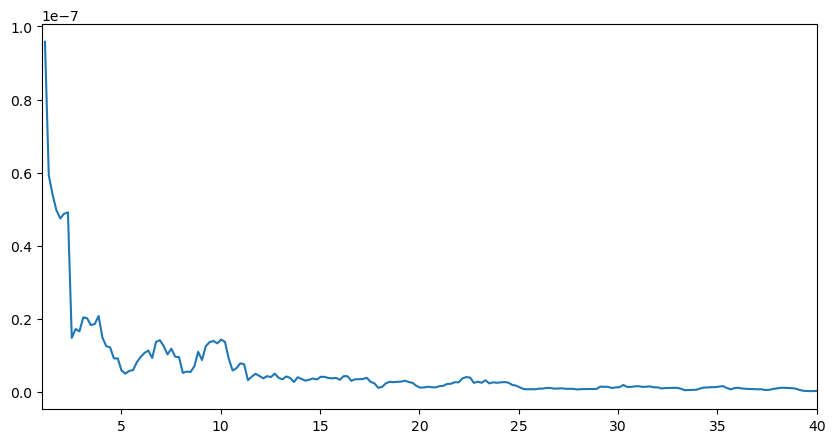

In [ ]:
# # plot psd
# plt.figure(figsize=(10, 5))
# channel = 30
# plt.plot(freqs, psds[channel,:])
# plt.xlim([1, 40])
